# Flight Delays and Weather: Data Engineering Final Project

## Overview

In this project, I build a full data engineering pipeline to study how weather patterns
relate to flight delays at four major U.S. airports:

- John F. Kennedy International Airport (JFK)
- San Francisco International Airport (SFO)
- Phoenix Sky Harbor International Airport (PHX)
- Denver International Airport (DEN)

The pipeline follows the classic ETL process:

1. **Extract**
   - Flight data for January 2025 from the U.S. Bureau of Transportation Statistics (On-Time Performance dataset).
   - Historical daily weather data from the Open-Meteo API for each airport.

2. **Transform**
   - Clean and filter raw flight records.
   - Normalize data into relational tables (airports, flights, daily_weather).
   - Aggregate daily flights and weather into weekly metrics.
   - Produce a final analytical table: `weekly_flight_weather_metrics`.

3. **Load**
   - Load the transformed tables into a MySQL relational database.
   - Run SQL queries to explore relationships between weather and delays.

4. **Visualization**
   - Build a Streamlit dashboard that allows interactive exploration of
     weekly delay metrics and weather patterns.

## End Goal

The main analytical end product is a **weekly, per-airport table**:

`weekly_flight_weather_metrics` with:

- `airport_id`
- `week_start_date`
- `avg_dep_delay_minutes`
- `avg_arr_delay_minutes`
- `percent_delayed_15`
- `weekly_temp_avg_c`
- `weekly_precip_mm`
- `weekly_wind_speed_ms`

This table supports both SQL queries and an interactive Streamlit dashboard.


In [1]:
!pip install plotly pandas numpy requests statsmodels

In [2]:
# 1. Imports & basic setup

import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


## 1. Extract: Flight Data (January 2025)

In this section I load the On-Time Performance flight dataset for January 2025.
The source is the U.S. Bureau of Transportation Statistics (BTS) On-Time dataset
exported to CSV. Each row represents a single flight leg and includes
dates, times, airport codes, and delay information.

Steps:

1. Read the full CSV into a Pandas DataFrame.
2. Filter to flights where the **origin airport** is one of:
   - JFK
   - SFO
   - PHX
   - DEN
3. Select only the columns needed for this project.
4. Perform basic exploration to understand the structure and quality of the data.


In [3]:
# 1.1 Load January 2025 flight data
flight_csv_path = "data/compressed_data.csv.gz"

flights_raw = pd.read_csv(flight_csv_path, compression= "gzip")

flights_raw.head()


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_FIPS,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME
0,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,N101NN,164,14771,1477104,32457,SFO,"San Francisco, CA",CA,6,California,91,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,1030,1024.0,-6.0,0.0,0.0,-1.0,1000-1059,11.0,1035.0,1826.0,6.0,1912,1832.0,-40.0,0.0,0.0,-2.0,1900-1959,0.0,NaN,0.0,342.0,308.0,291.0,1.0,2586.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,N101NN,76,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,14771,1477104,32457,SFO,"San Francisco, CA",CA,6,California,91,600,557.0,-3.0,0.0,0.0,-1.0,0600-0659,16.0,613.0,919.0,6.0,940,925.0,-15.0,0.0,0.0,-1.0,0900-0959,0.0,NaN,0.0,400.0,388.0,366.0,1.0,2586.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,N102UW,3244,14683,1468305,33214,SAT,"San Antonio, TX",TX,48,Texas,74,11057,1105703,31057,CLT,"Charlotte, NC",NC,37,North Carolina,36,819,817.0,-2.0,0.0,0.0,-1.0,0800-0859,13.0,830.0,1131.0,11.0,1206,1142.0,-24.0,0.0,0.0,-2.0,1200-1259,0.0,NaN,0.0,167.0,145.0,121.0,1.0,1095.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,N103NN,185,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,12892,1289208,32575,LAX,"Los Angeles, CA",CA,6,California,91,2100,2052.0,-8.0,0.0,0.0,-1.0,2100-2159,21.0,2113.0,15.0,12.0,29,27.0,-2.0,0.0,0.0,-1.0,0001-0559,0.0,NaN,0.0,389.0,395.0,362.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,19805,AA,N103NN,2455,10721,1072102,30721,BOS,"Boston, MA",MA,25,Massachusetts,13,12892,1289208,32575,LAX,"Los Angeles, CA",CA,6,California,91,801,756.0,-5.0,0.0,0.0,-1.0,0800-0859,15.0,811.0,1055.0,16.0,1140,1111.0,-29.0,0.0,0.0,-2.0,1100-1159,0.0,NaN,0.0,399.0,375.0,344.0,1.0,2611.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Note: The original raw data file exceeded Gradescope’s upload limit (170 MB), so I compressed it using gzip. For that reason, the notebook reads the dataset with the appropriate compression argument. The compressed file is unchanged aside from size reduction and comes directly from the original BTS source.

### 1.1 Load January 2025 flight data

The preview of flights_raw confirms that the January 2025 on-time reporting file loaded correctly and includes the expected flight-level fields (year, month, day, carrier, origin/destination, times, and delay metrics). There seems to be a lot of columns with operational data that contain missing data... I will definitely drop these. Overall, the sample rows look like complete, realistic flight records for various routes and carriers.

In [4]:
# 1.2 Inspect schema and summary
flights_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 64 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   YEAR                   539747 non-null  int64  
 1   QUARTER                539747 non-null  int64  
 2   MONTH                  539747 non-null  int64  
 3   DAY_OF_MONTH           539747 non-null  int64  
 4   DAY_OF_WEEK            539747 non-null  int64  
 5   FL_DATE                539747 non-null  object 
 6   OP_UNIQUE_CARRIER      539747 non-null  object 
 7   OP_CARRIER_AIRLINE_ID  539747 non-null  int64  
 8   OP_CARRIER             539747 non-null  object 
 9   TAIL_NUM               537217 non-null  object 
 10  OP_CARRIER_FL_NUM      539747 non-null  int64  
 11  ORIGIN_AIRPORT_ID      539747 non-null  int64  
 12  ORIGIN_AIRPORT_SEQ_ID  539747 non-null  int64  
 13  ORIGIN_CITY_MARKET_ID  539747 non-null  int64  
 14  ORIGIN                 539747 non-nu

### 1.2 Inspect schema and summary

The info() output shows that the dataset has 539,747 rows and 64 columns, with a mix of integers, floats, and string fields. Core scheduling and identification columns are fully populated, while many detailed delay fields (like CARRIER_DELAY, WEATHER_DELAY, etc.) are sparse, which is important to keep in mind for later analysis and modeling.

In [5]:
# 1.3 Filter to flights with origin in our four airports
target_airports = ["JFK", "SFO", "PHX", "DEN"]

flights = flights_raw[flights_raw["ORIGIN"].isin(target_airports)].copy()
print(f"Rows after filtering to JFK, SFO, PHX, DEN origins: {len(flights)}")

flights[["YEAR", "MONTH", "DAY_OF_MONTH", "ORIGIN", "DEST", "FL_DATE", "DEP_TIME", "ARR_TIME", "DEP_DELAY", "ARR_DELAY"]].head()


Rows after filtering to JFK, SFO, PHX, DEN origins: 59854


,YEAR,MONTH,DAY_OF_MONTH,ORIGIN,DEST,FL_DATE,DEP_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY
0,2025,1,1,SFO,JFK,1/1/2025 12:00:00 AM,1024.0,1832.0,-6.0,-40.0
1,2025,1,1,JFK,SFO,1/1/2025 12:00:00 AM,557.0,925.0,-3.0,-15.0
3,2025,1,1,JFK,LAX,1/1/2025 12:00:00 AM,2052.0,27.0,-8.0,-2.0
6,2025,1,1,PHX,SMF,1/1/2025 12:00:00 AM,1134.0,1245.0,30.0,33.0
9,2025,1,1,PHX,OMA,1/1/2025 12:00:00 AM,2026.0,2354.0,1.0,-7.0


### 1.3 Filter to four origin airports

After filtering to flights that depart from JFK, SFO, PHX, and DEN, the dataset shrinks to 59,854 rows, confirming that these four airports are a manageable subset of the full US dataset. The sample rows show that we still retain key fields like dates, times, and delay values for a variety of routes out of these origins.

In [6]:
# 1.4 Select relevant columns
columns_needed = [
    "YEAR", "MONTH", "DAY_OF_MONTH", "FL_DATE",
    "OP_UNIQUE_CARRIER", "OP_CARRIER", "OP_CARRIER_FL_NUM",
    "ORIGIN", "DEST",
    "CRS_DEP_TIME", "DEP_TIME", "DEP_DELAY", "DEP_DELAY_NEW",
    "CRS_ARR_TIME", "ARR_TIME", "ARR_DELAY", "ARR_DELAY_NEW",
    "CANCELLED", "DIVERTED",
    "DISTANCE"
]

flights = flights[columns_needed].copy()
flights.head()


,YEAR,MONTH,DAY_OF_MONTH,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,CANCELLED,DIVERTED,DISTANCE
0,2025,1,1,1/1/2025 12:00:00 AM,AA,AA,164,SFO,JFK,1030,1024.0,-6.0,0.0,1912,1832.0,-40.0,0.0,0.0,0.0,2586.0
1,2025,1,1,1/1/2025 12:00:00 AM,AA,AA,76,JFK,SFO,600,557.0,-3.0,0.0,940,925.0,-15.0,0.0,0.0,0.0,2586.0
3,2025,1,1,1/1/2025 12:00:00 AM,AA,AA,185,JFK,LAX,2100,2052.0,-8.0,0.0,29,27.0,-2.0,0.0,0.0,0.0,2475.0
6,2025,1,1,1/1/2025 12:00:00 AM,AA,AA,1324,PHX,SMF,1104,1134.0,30.0,30.0,1212,1245.0,33.0,33.0,0.0,0.0,647.0
9,2025,1,1,1/1/2025 12:00:00 AM,AA,AA,2808,PHX,OMA,2025,2026.0,1.0,1.0,1,2354.0,-7.0,0.0,0.0,0.0,1037.0


### 1.4 Select relevant columns

By selecting the subset of columns, the flights table is reduced to the fields needed for analysis: date components, carrier identifiers, origin/destination, scheduled and actual times, delay metrics, cancellation/diversion flags, and distance. The head of the dataframe confirms that each row now focuses on the core features required to study delays without extra unused fields.

## 2. Extract: Airports Lookup Table

Next, I create a small lookup table for the four airports in this study.
Each row contains the IATA code, airport name, and approximate latitude/longitude.

This table will:

- Serve as a dimension table in the relational schema.
- Provide coordinates needed for the weather API calls.


In [7]:
airports = pd.DataFrame([
    ("JFK", "John F. Kennedy International Airport", 40.6413, -73.7781),
    ("SFO", "San Francisco International Airport", 37.6213, -122.3790),
    ("PHX", "Phoenix Sky Harbor International Airport", 33.4342, -112.0116),
    ("DEN", "Denver International Airport", 39.8561, -104.6737),
], columns=["iata_code", "airport_name", "latitude", "longitude"])

airports


,iata_code,airport_name,latitude,longitude
0,JFK,John F. Kennedy International Airport,40.6413,-73.7781
1,SFO,San Francisco International Airport,37.6213,-122.3790
2,PHX,Phoenix Sky Harbor International Airport,33.4342,-112.0116
3,DEN,Denver International Airport,39.8561,-104.6737


### 2.1 Extract: Airports lookup table

The airports dataframe correctly defines a small lookup table with one row per airport, containing IATA code, full airport name, latitude, and longitude for JFK, SFO, PHX, and DEN. This confirms I have a clean, structured reference for joining spatial / weather data to the flight records.

## 3. Extract: Historical Weather Data (Open-Meteo API)

To study the impact of weather on delays, I collect historical daily weather
data for each airport using the **Open-Meteo** API.

For each airport (JFK, SFO, PHX, DEN) and for the month of January 2025, I request:

- Daily mean temperature (°C)
- Daily total precipitation (mm)
- Daily maximum wind speed (m/s)

Steps:

1. Define a helper function `fetch_weather` that:
   - Calls the Open-Meteo API with latitude, longitude, and date range.
   - Parses the JSON into a Pandas DataFrame.
2. Loop over the four airports and build a combined `daily_weather` table.
3. Inspect the resulting DataFrame for completeness and consistency.


In [8]:
import json

def fetch_weather(lat, lon, start_date, end_date):
    """
    Fetch daily historical weather for given coordinates and date range
    from Open-Meteo's archive API.
    
    Returns a DataFrame with:
      - date
      - temp_avg_c
      - precip_mm
      - wind_speed_ms
    """
    url = "https://archive-api.open-meteo.com/v1/archive"  # <-- key change

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,      # e.g. "2025-01-01"
        "end_date": end_date,          # e.g. "2025-01-31"
        "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
        "timezone": "UTC"
    }

    response = requests.get(url, params=params)

    # Helpful debugging if anything goes wrong again
    if response.status_code != 200:
        print("Request URL:", response.url)
        print("Status code:", response.status_code)
        print("Response text (first 500 chars):")
        print(response.text[:500])
        response.raise_for_status()

    data = response.json()
    daily = data["daily"]

    df = pd.DataFrame({
        "date": daily["time"],
        "temp_avg_c": daily["temperature_2m_mean"],
        "precip_mm": daily["precipitation_sum"],
        "wind_speed_ms": daily["windspeed_10m_max"],
    })

    return df

In [9]:
# 3.2 Define date range for January 2025
start_date = "2025-01-01"
end_date = "2025-01-31"

weather_frames = []

for _, row in airports.iterrows():
    iata = row["iata_code"]
    lat = row["latitude"]
    lon = row["longitude"]
    print(f"Fetching weather for {iata}...")
    
    df = fetch_weather(lat, lon, start_date, end_date)
    df["iata_code"] = iata
    weather_frames.append(df)

daily_weather = pd.concat(weather_frames, ignore_index=True)

daily_weather.head()


Fetching weather for JFK...
Fetching weather for SFO...
Fetching weather for PHX...
Fetching weather for DEN...


,date,temp_avg_c,precip_mm,wind_speed_ms,iata_code
0,2025-01-01,8.5,12.3,25.8,JFK
1,2025-01-02,3.5,0.0,26.3,JFK
2,2025-01-03,0.9,0.0,22.0,JFK
3,2025-01-04,-0.8,0.0,27.9,JFK
4,2025-01-05,-1.9,0.0,22.1,JFK


### 3.2 Fetch January 2025 weather for each airport

The loop prints progress messages for each airport and the preview of daily_weather shows that the API calls succeeded. For JFK (and similarly for the other airports), you get one row per day in January 2025, with sensible weather values (date, temp_avg_c, precip_mm, wind_speed_ms) plus the iata_code, confirming that daily weather has been fetched and labeled per airport.

In [10]:
# 3.3 Convert date column to datetime and inspect
daily_weather["date"] = pd.to_datetime(daily_weather["date"])
daily_weather.info()
daily_weather.groupby("iata_code")["date"].count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           124 non-null    datetime64[ns]
 1   temp_avg_c     124 non-null    float64       
 2   precip_mm      124 non-null    float64       
 3   wind_speed_ms  124 non-null    float64       
 4   iata_code      124 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 5.0+ KB


iata_code
DEN    31
JFK    31
PHX    31
SFO    31
Name: date, dtype: int64

### 3.3 Inspect weather schema and coverage

The info() and groupby outputs show that the combined daily_weather dataframe has 124 rows and 5 columns, with no missing values. Each of the four airports has 31 days of data, confirming complete coverage for all of January 2025 and that the date column has been correctly converted to a datetime type.

## 4. Transform: Clean and Prepare Flight Data

This section cleans the flight dataset and prepares it for analysis and loading
into the relational schema.

Key steps:

1. Convert `FL_DATE` from string to `datetime`.
2. Filter out cancelled or diverted flights.
3. Use the delay columns to define:
   - `dep_delay_minutes`
   - `arr_delay_minutes`
   - `is_delayed_15` (arrival delay > 15 minutes).
4. Keep only columns that map cleanly into the `flights` table.
5. Perform basic sanity checks on distributions of delay values.


In [11]:
# 4.1 Convert FL_DATE to datetime
flights["FL_DATE"] = pd.to_datetime(flights["FL_DATE"])

# 4.2 Filter out cancelled or diverted flights
flights = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].copy()
print(f"Rows after removing cancelled/diverted: {len(flights)}")


Rows after removing cancelled/diverted: 59004


C:\Users\vivth\AppData\Local\Temp\ipykernel_17488\3284947568.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights["FL_DATE"] = pd.to_datetime(flights["FL_DATE"])


In [12]:
# 4.3 Create cleaned delay columns
# Use ARR_DELAY_NEW and DEP_DELAY_NEW if available; fall back to ARR_DELAY etc if not.

flights["dep_delay_minutes"] = flights["DEP_DELAY_NEW"].fillna(flights["DEP_DELAY"])
flights["arr_delay_minutes"] = flights["ARR_DELAY_NEW"].fillna(flights["ARR_DELAY"])

# 4.4 Define is_delayed_15 based on arrival delay > 15 minutes
flights["is_delayed_15"] = flights["arr_delay_minutes"] > 15

flights[["FL_DATE", "ORIGIN", "DEST", "dep_delay_minutes", "arr_delay_minutes", "is_delayed_15"]].head()


,FL_DATE,ORIGIN,DEST,dep_delay_minutes,arr_delay_minutes,is_delayed_15
0,2025-01-01,SFO,JFK,0.0,0.0,False
1,2025-01-01,JFK,SFO,0.0,0.0,False
3,2025-01-01,JFK,LAX,0.0,0.0,False
6,2025-01-01,PHX,SMF,30.0,33.0,True
9,2025-01-01,PHX,OMA,1.0,0.0,False


In [13]:
# 4.5 Basic distributions of delays
flights["dep_delay_minutes"].describe()
flights["arr_delay_minutes"].describe()
flights["is_delayed_15"].mean()  # average fraction of delayed flights


np.float64(0.18134363771947665)

## 5. Transform: Normalize Airports and Weather

Now I normalize the reference data:

1. Assign surrogate integer keys (`airport_id`) to each airport.
2. Use these keys to link:
   - `flights` (via `ORIGIN`) → `origin_airport_id`
   - `daily_weather` (via `iata_code`) → `airport_id`
3. This step prepares our data for relational loading and for later aggregations.


In [14]:
# 5.1 Assign airport_id
airports = airports.copy()
airports["airport_id"] = range(1, len(airports) + 1)

airports


,iata_code,airport_name,latitude,longitude,airport_id
0,JFK,John F. Kennedy International Airport,40.6413,-73.7781,1
1,SFO,San Francisco International Airport,37.6213,-122.3790,2
2,PHX,Phoenix Sky Harbor International Airport,33.4342,-112.0116,3
3,DEN,Denver International Airport,39.8561,-104.6737,4


In [15]:
# 5.2 Map origin airport to airport_id (for now we focus on origin-based delays)
iata_to_id = dict(zip(airports["iata_code"], airports["airport_id"]))

flights["origin_airport_id"] = flights["ORIGIN"].map(iata_to_id)
flights["dest_airport_id"] = flights["DEST"].map(iata_to_id)  # may be NaN if dest not in our 4 airports

flights[["FL_DATE", "ORIGIN", "origin_airport_id"]].head()


,FL_DATE,ORIGIN,origin_airport_id
0,2025-01-01,SFO,2
1,2025-01-01,JFK,1
3,2025-01-01,JFK,1
6,2025-01-01,PHX,3
9,2025-01-01,PHX,3


In [16]:
# 5.3 Attach airport_id to weather table
daily_weather = daily_weather.merge(
    airports[["iata_code", "airport_id"]],
    on="iata_code",
    how="left"
)

daily_weather.head()


,date,temp_avg_c,precip_mm,wind_speed_ms,iata_code,airport_id
0,2025-01-01,8.5,12.3,25.8,JFK,1
1,2025-01-02,3.5,0.0,26.3,JFK,1
2,2025-01-03,0.9,0.0,22.0,JFK,1
3,2025-01-04,-0.8,0.0,27.9,JFK,1
4,2025-01-05,-1.9,0.0,22.1,JFK,1


## 6. Transform: Weekly Aggregations and Final Analytical Table

The final goal is a weekly table that combines:

- Flight delay metrics (per origin airport)
- Weather metrics (per airport)

Steps:

1. Create a `week_start` column for both flights and weather, representing the
   Monday of each week.
2. Aggregate flights by `(origin_airport_id, week_start)`:
   - Mean departure delay
   - Mean arrival delay
   - Percentage of flights with arrival delay > 15 minutes
3. Aggregate weather by `(airport_id, week_start)`:
   - Mean daily temperature
   - Total weekly precipitation
   - Mean daily maximum wind speed
4. Join the two aggregated tables to create `weekly_flight_weather_metrics`.


In [17]:
# 6.1 Create week_start for flights (Monday of each week)
flights["week_start"] = flights["FL_DATE"] - flights["FL_DATE"].dt.weekday * pd.to_timedelta(1, unit="D")

weekly_flights = flights.groupby(["origin_airport_id", "week_start"]).agg(
    avg_dep_delay_minutes=("dep_delay_minutes", "mean"),
    avg_arr_delay_minutes=("arr_delay_minutes", "mean"),
    percent_delayed_15=("is_delayed_15", "mean")
).reset_index()

weekly_flights.head()


,origin_airport_id,week_start,avg_dep_delay_minutes,avg_arr_delay_minutes,percent_delayed_15
0,1,2024-12-30,15.138026,16.133885,0.243616
1,1,2025-01-06,19.925234,21.122595,0.271578
2,1,2025-01-13,9.444632,11.155143,0.144463
3,1,2025-01-20,11.138008,15.072899,0.228715
4,1,2025-01-27,7.909091,7.103788,0.077273


In [18]:
# 6.2 Create week_start for weather
daily_weather["week_start"] = daily_weather["date"] - daily_weather["date"].dt.weekday * pd.to_timedelta(1, unit="D")

weekly_weather = daily_weather.groupby(["airport_id", "week_start"]).agg(
    weekly_temp_avg_c=("temp_avg_c", "mean"),
    weekly_precip_mm=("precip_mm", "sum"),
    weekly_wind_speed_ms=("wind_speed_ms", "mean")
).reset_index()

weekly_weather.head()


,airport_id,week_start,weekly_temp_avg_c,weekly_precip_mm,weekly_wind_speed_ms
0,1,2024-12-30,2.040000,12.3,24.820000
1,1,2025-01-06,-2.214286,3.4,24.314286
2,1,2025-01-13,0.128571,3.8,18.471429
3,1,2025-01-20,-6.528571,5.8,14.228571
4,1,2025-01-27,1.880000,4.2,21.840000


In [19]:
# 6.3 Join weekly flights and weather into final table
weekly = weekly_flights.merge(
    weekly_weather,
    left_on=["origin_airport_id", "week_start"],
    right_on=["airport_id", "week_start"],
    how="inner"
)

# Rename airport_id consistently
weekly.rename(columns={"origin_airport_id": "airport_id"}, inplace=True)

# Drop repeated airport_id column
weekly = weekly.loc[:, ~weekly.columns.duplicated()]

weekly.head()


,airport_id,week_start,avg_dep_delay_minutes,avg_arr_delay_minutes,percent_delayed_15,weekly_temp_avg_c,weekly_precip_mm,weekly_wind_speed_ms
0,1,2024-12-30,15.138026,16.133885,0.243616,2.040000,12.3,24.820000
1,1,2025-01-06,19.925234,21.122595,0.271578,-2.214286,3.4,24.314286
2,1,2025-01-13,9.444632,11.155143,0.144463,0.128571,3.8,18.471429
3,1,2025-01-20,11.138008,15.072899,0.228715,-6.528571,5.8,14.228571
4,1,2025-01-27,7.909091,7.103788,0.077273,1.880000,4.2,21.840000


In [20]:
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   airport_id             20 non-null     int64         
 1   week_start             20 non-null     datetime64[ns]
 2   avg_dep_delay_minutes  20 non-null     float64       
 3   avg_arr_delay_minutes  20 non-null     float64       
 4   percent_delayed_15     20 non-null     float64       
 5   weekly_temp_avg_c      20 non-null     float64       
 6   weekly_precip_mm       20 non-null     float64       
 7   weekly_wind_speed_ms   20 non-null     float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 1.4 KB


## 7. Load: MySQL Relational Database (mysql.connector)

In this section, I load the normalized tables into a MySQL database using the
`mysql.connector` library (the same approach used in class).

I will:

1. Connect to a MySQL database (`flight_weather_db`).
2. Create tables using explicit `CREATE TABLE` DDL statements:
   - `airports`
   - `flights`
   - `daily_weather`
   - `weekly_flight_weather_metrics`
3. Insert rows from my Pandas DataFrames into each table using `executemany`.
4. Run a few sample queries to verify that the data loaded correctly.


In [21]:
import mysql.connector
import pandas as pd

mysql_address   = '127.0.0.1'
mysql_username  = 'root'          
mysql_password  = 'GoombaSQL1!'    
mysql_database  = 'ista322_db'    

def get_conn_cur():
    cnx = mysql.connector.connect(
        user=mysql_username,
        password=mysql_password,
        host=mysql_address,
        database=mysql_database,
        port='3306'
    )
    return cnx, cnx.cursor()

def run_query(query_string):
    """Run a query and return the result as a DataFrame."""
    conn, cur = get_conn_cur()
    cur.execute(query_string)
    my_data = cur.fetchall()
    result_df = pd.DataFrame(my_data, columns=cur.column_names)
    cur.close()
    conn.close()
    return result_df

def sql_head(table_name):
    """Return first 5 rows of a table as a DataFrame."""
    conn, cur = get_conn_cur()
    table_rows_query = "SELECT * FROM %s LIMIT 5;" % table_name
    cur.execute(table_rows_query)
    my_data = cur.fetchall()
    df = pd.DataFrame(my_data, columns=cur.column_names)
    cur.close()
    conn.close()
    return df


### 7.1 Creating the relational tables

Here I define the relational schema and create the tables in MySQL.
The schema matches the normalized design used earlier:

- `airports` – airport dimension table
- `flights` – individual flight records
- `daily_weather` – daily weather for each airport
- `weekly_flight_weather_metrics` – final analytical fact table


In [22]:
# Drop tables if they already exist (to reload cleanly)
drop_ddls = [
    "DROP TABLE IF EXISTS weekly_flight_weather_metrics;",
    "DROP TABLE IF EXISTS daily_weather;",
    "DROP TABLE IF EXISTS flights;",
    "DROP TABLE IF EXISTS airports;"
]

for ddl in drop_ddls:
    run_query(ddl)

# Create tables
create_airports = """
CREATE TABLE airports (
    airport_id INT PRIMARY KEY,
    iata_code VARCHAR(5) NOT NULL,
    airport_name VARCHAR(100),
    latitude DOUBLE,
    longitude DOUBLE
);
"""

create_flights = """
CREATE TABLE flights (
    flight_id INT AUTO_INCREMENT PRIMARY KEY,
    flight_date DATE NOT NULL,
    carrier VARCHAR(10),
    op_unique_carrier VARCHAR(10),
    flight_number VARCHAR(10),
    origin_airport_id INT,
    dest_airport_id INT,
    dep_time VARCHAR(10),
    arr_time VARCHAR(10),
    dep_delay_minutes INT,
    arr_delay_minutes INT,
    is_delayed_15 BOOLEAN,
    FOREIGN KEY (origin_airport_id) REFERENCES airports(airport_id),
    FOREIGN KEY (dest_airport_id) REFERENCES airports(airport_id)
);
"""

create_daily_weather = """
CREATE TABLE daily_weather (
    weather_id INT AUTO_INCREMENT PRIMARY KEY,
    airport_id INT NOT NULL,
    date DATE NOT NULL,
    temp_avg_c DOUBLE,
    precip_mm DOUBLE,
    wind_speed_ms DOUBLE,
    FOREIGN KEY (airport_id) REFERENCES airports(airport_id)
);
"""

create_weekly_metrics = """
CREATE TABLE weekly_flight_weather_metrics (
    airport_id INT NOT NULL,
    week_start_date DATE NOT NULL,
    avg_dep_delay_minutes DOUBLE,
    avg_arr_delay_minutes DOUBLE,
    percent_delayed_15 DOUBLE,
    weekly_temp_avg_c DOUBLE,
    weekly_precip_mm DOUBLE,
    weekly_wind_speed_ms DOUBLE,
    PRIMARY KEY (airport_id, week_start_date),
    FOREIGN KEY (airport_id) REFERENCES airports(airport_id)
);
"""

for ddl in [create_airports, create_flights, create_daily_weather, create_weekly_metrics]:
    run_query(ddl)

print("Tables created in MySQL.")


Tables created in MySQL.


### 7.2 Inserting data from Pandas into MySQL

To move data from my Pandas DataFrames into MySQL, I define a helper function
that uses `executemany` with parameterized INSERT statements. This works with
our existing `get_conn_cur` function.


In [23]:
def insert_dataframe(df, table_name):
    """
    Insert a Pandas DataFrame into a MySQL table using executemany.
    - Forces columns to object dtype so pandas.NA can be replaced.
    - Converts pandas.NA / NaN / NaT to None.
    - Converts numpy scalars to native Python scalars.
    """
    conn, cur = get_conn_cur()

    # Work on a copy
    df_clean = df.copy()

    # Force everything to object so we can safely put None in there
    df_clean = df_clean.astype(object)

    # Replace missing values (NaN, NaT, pandas.NA) with None
    df_clean = df_clean.where(df_clean.notnull(), None)

    cols = ", ".join(df_clean.columns)
    placeholders = ", ".join(["%s"] * len(df_clean.columns))
    sql = f"INSERT INTO {table_name} ({cols}) VALUES ({placeholders});"

    def convert_value(v):
        # Explicitly handle pandas.NA
        if v is pd.NA:
            return None
        # numpy scalar → Python scalar
        if isinstance(v, np.generic):
            return v.item()
        return v

    data = [
        tuple(convert_value(v) for v in row)
        for row in df_clean.itertuples(index=False, name=None)
    ]

    cur.executemany(sql, data)
    conn.commit()
    cur.close()
    conn.close()
    print(f"Inserted {len(df_clean)} rows into {table_name}.")

In [24]:
# Prepare airports DataFrame: must match airports table columns
airports_sql = airports[["airport_id", "iata_code", "airport_name", "latitude", "longitude"]].copy()

insert_dataframe(airports_sql, "airports")


Inserted 4 rows into airports.


In [25]:
# 7.3.2 Insert `flights` table

# Make sure FL_DATE is datetime
flights["FL_DATE"] = pd.to_datetime(flights["FL_DATE"])

# Keep only rows that have an origin_airport_id
flights = flights[flights["origin_airport_id"].notna()].copy()

# Build the insert DataFrame in the exact order of the flights table
flights_sql = pd.DataFrame({
    "flight_date": flights["FL_DATE"].dt.date,                       # Python date
    "carrier": flights["OP_CARRIER"].astype(str),
    "op_unique_carrier": flights["OP_UNIQUE_CARRIER"].astype(str),
    "flight_number": flights["OP_CARRIER_FL_NUM"].astype(str),
    "origin_airport_id": flights["origin_airport_id"].astype(int),
    # dest_airport_id can be NaN; leave as-is, helper will turn NaN -> None
    "dest_airport_id": flights["dest_airport_id"],
    "dep_time": flights["DEP_TIME"].astype(str),
    "arr_time": flights["ARR_TIME"].astype(str),
    "dep_delay_minutes": flights["dep_delay_minutes"].fillna(0),
    "arr_delay_minutes": flights["arr_delay_minutes"].fillna(0),
    "is_delayed_15": flights["is_delayed_15"].astype(int)
})

print("flights_sql columns:", list(flights_sql.columns))
display(flights_sql.head())

insert_dataframe(flights_sql, "flights")


flights_sql columns: ['flight_date', 'carrier', 'op_unique_carrier', 'flight_number', 'origin_airport_id', 'dest_airport_id', 'dep_time', 'arr_time', 'dep_delay_minutes', 'arr_delay_minutes', 'is_delayed_15']


,flight_date,carrier,op_unique_carrier,flight_number,origin_airport_id,dest_airport_id,dep_time,arr_time,dep_delay_minutes,arr_delay_minutes,is_delayed_15
0,2025-01-01,AA,AA,164,2,1.0,1024.0,1832.0,0.0,0.0,0
1,2025-01-01,AA,AA,76,1,2.0,557.0,925.0,0.0,0.0,0
3,2025-01-01,AA,AA,185,1,NaN,2052.0,27.0,0.0,0.0,0
6,2025-01-01,AA,AA,1324,3,NaN,1134.0,1245.0,30.0,33.0,1
9,2025-01-01,AA,AA,2808,3,NaN,2026.0,2354.0,1.0,0.0,0


Inserted 59004 rows into flights.


In [26]:
# Prepare daily_weather DataFrame
daily_weather_sql = daily_weather[[
    "airport_id",
    "date",
    "temp_avg_c",
    "precip_mm",
    "wind_speed_ms"
]].copy()

insert_dataframe(daily_weather_sql, "daily_weather")


Inserted 124 rows into daily_weather.


In [27]:
# Prepare weekly metrics DataFrame

weekly_sql = pd.DataFrame({
    "airport_id": weekly["airport_id"].astype(int),
    "week_start_date": weekly["week_start"].dt.date,
    "avg_dep_delay_minutes": weekly["avg_dep_delay_minutes"],
    "avg_arr_delay_minutes": weekly["avg_arr_delay_minutes"],
    "percent_delayed_15": weekly["percent_delayed_15"],
    "weekly_temp_avg_c": weekly["weekly_temp_avg_c"],
    "weekly_precip_mm": weekly["weekly_precip_mm"],
    "weekly_wind_speed_ms": weekly["weekly_wind_speed_ms"]
})

insert_dataframe(weekly_sql, "weekly_flight_weather_metrics")



Inserted 20 rows into weekly_flight_weather_metrics.


### 7.4 Verifying the loaded tables

Finally, I confirm that the data was loaded correctly by previewing each table
and running a simple analytical query using `run_query`.


In [28]:
# Preview a few rows from each table
print("airports:")
display(sql_head("airports"))

print("flights:")
display(sql_head("flights"))

print("daily_weather:")
display(sql_head("daily_weather"))

print("weekly_flight_weather_metrics:")
display(sql_head("weekly_flight_weather_metrics"))


airports:


,airport_id,iata_code,airport_name,latitude,longitude
0,1,JFK,John F. Kennedy International Airport,40.6413,-73.7781
1,2,SFO,San Francisco International Airport,37.6213,-122.3790
2,3,PHX,Phoenix Sky Harbor International Airport,33.4342,-112.0116
3,4,DEN,Denver International Airport,39.8561,-104.6737


flights:


,flight_id,flight_date,carrier,op_unique_carrier,flight_number,origin_airport_id,dest_airport_id,dep_time,arr_time,dep_delay_minutes,arr_delay_minutes,is_delayed_15
0,1,2025-01-01,AA,AA,164,2,1.0,1024.0,1832.0,0,0,0
1,2,2025-01-01,AA,AA,76,1,2.0,557.0,925.0,0,0,0
2,3,2025-01-01,AA,AA,185,1,NaN,2052.0,27.0,0,0,0
3,4,2025-01-01,AA,AA,1324,3,NaN,1134.0,1245.0,30,33,1
4,5,2025-01-01,AA,AA,2808,3,NaN,2026.0,2354.0,1,0,0


daily_weather:


,weather_id,airport_id,date,temp_avg_c,precip_mm,wind_speed_ms
0,1,1,2025-01-01,8.5,12.3,25.8
1,2,1,2025-01-02,3.5,0.0,26.3
2,3,1,2025-01-03,0.9,0.0,22.0
3,4,1,2025-01-04,-0.8,0.0,27.9
4,5,1,2025-01-05,-1.9,0.0,22.1


weekly_flight_weather_metrics:


,airport_id,week_start_date,avg_dep_delay_minutes,avg_arr_delay_minutes,percent_delayed_15,weekly_temp_avg_c,weekly_precip_mm,weekly_wind_speed_ms
0,1,2024-12-30,15.138026,16.133885,0.243616,2.040000,12.3,24.820000
1,1,2025-01-06,19.925234,21.122595,0.271578,-2.214286,3.4,24.314286
2,1,2025-01-13,9.444632,11.155143,0.144463,0.128571,3.8,18.471429
3,1,2025-01-20,11.138008,15.072899,0.228715,-6.528571,5.8,14.228571
4,1,2025-01-27,7.909091,7.103788,0.077273,1.880000,4.2,21.840000


## 8. Exploration with SQL Queries

Now that the data is loaded into MySQL, I use SQL to explore patterns
in the `weekly_flight_weather_metrics` table joined with the `airports`
dimension.

These queries demonstrate typical analytical questions we can answer:

1. Which airport has the highest average weekly departure delay?
2. What fraction of flights are delayed more than 15 minutes at each airport?
3. How do weekly delays at a single airport evolve over January 2025?
4. Do wetter weeks tend to have higher delays?
5. Which weeks had the most extreme wind speeds, and how bad were delays?


### 8.1 Query 1 – Average weekly departure delay by airport

This query computes the average **weekly departure delay** for each airport
over the period in my dataset. It helps identify which of the four airports
(JFK, SFO, PHX, DEN) tends to have the worst departure delays on average.


In [29]:
q1 = """
SELECT a.iata_code,
       ROUND(AVG(w.avg_dep_delay_minutes), 2) AS avg_weekly_dep_delay
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
GROUP BY a.iata_code
ORDER BY avg_weekly_dep_delay DESC;
"""

run_query(q1)


,iata_code,avg_weekly_dep_delay
0,DEN,14.98
1,JFK,12.71
2,SFO,10.53
3,PHX,9.24


What the results show: 
- DEN has the highest average weekly delay at about 15 minutes.
- JFK follows with roughly 13 minutes per week.
- SFO comes in lower at about 10.5 minutes.
- PHX has the lowest average delays at a little over 9 minutes.

### 8.2 Query 2 – Percentage of delayed flights (> 15 minutes) by airport

The `percent_delayed_15` column in `weekly_flight_weather_metrics` stores
the fraction of flights in each week that arrived more than 15 minutes late.

This query aggregates that metric to show the **average percentage of delayed
flights** per airport.


In [30]:
q2 = """
SELECT a.iata_code,
       ROUND(AVG(w.percent_delayed_15) * 100, 1) AS avg_pct_delayed_over_15
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
GROUP BY a.iata_code
ORDER BY avg_pct_delayed_over_15 DESC;
"""

run_query(q2)


,iata_code,avg_pct_delayed_over_15
0,DEN,23.8
1,JFK,19.3
2,SFO,13.0
3,PHX,11.8


What the results show
- DEN has the largest share of longer delays at about 23.8%.
- JFK follows with roughly 19.3%.
- SFO sits lower at around 13%.
- PHX has the fewest long delays at about 11.8%.

### 8.3 Query 3a – Weekly delay trend for JFK

This query pulls the weekly departure delay for JFK, ordered by week start
date, to see how delays changed over time in January 2025.


In [31]:
q3a = """
SELECT w.week_start_date,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
WHERE a.iata_code = 'JFK'
ORDER BY w.week_start_date;
"""

run_query(q3a)


,week_start_date,avg_dep_delay_minutes
0,2024-12-30,15.138026
1,2025-01-06,19.925234
2,2025-01-13,9.444632
3,2025-01-20,11.138008
4,2025-01-27,7.909091


What the results show
- Delays start moderately high at around 15 minutes in the week of Dec 30.
- They jump to roughly 20 minutes in the week of Jan 6, the highest point in the series.
- They drop sharply the following week to about 9.4 minutes.
- A small uptick appears on Jan 20, reaching a little above 11 minutes.
- By Jan 27, delays fall to the lowest level of the month at about 7.9 minutes.

### 8.3 Query 3b – Weekly delay trend for SFO

This query pulls the weekly departure delay for SFO, ordered by week start
date, to see how delays changed over time in January 2025.


In [32]:
q3b = """
SELECT w.week_start_date,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
WHERE a.iata_code = 'SFO'
ORDER BY w.week_start_date;
"""

run_query(q3b)


,week_start_date,avg_dep_delay_minutes
0,2024-12-30,16.204112
1,2025-01-06,13.061571
2,2025-01-13,7.509036
3,2025-01-20,8.485338
4,2025-01-27,7.389020


What the results show
- Delays start at about 16 minutes the week of Dec 30, then drop to around 13 minutes the following week.
- They fall sharply by Jan 13 to just over 7.5 minutes, the biggest improvement in the series.
- There’s a small rebound on Jan 20, where delays rise to about 8.5 minutes.
- By Jan 27, delays edge down again to roughly 7.4 minutes, the lowest point in the five-week stretch.


### 8.3 Query 3c – Weekly delay trend for PHX

This query pulls the weekly departure delay for PHX, ordered by week start
date, to see how delays changed over time in January 2025.


In [33]:
q3c = """
SELECT w.week_start_date,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
WHERE a.iata_code = 'PHX'
ORDER BY w.week_start_date;
"""

run_query(q3c)


,week_start_date,avg_dep_delay_minutes
0,2024-12-30,14.641860
1,2025-01-06,10.967147
2,2025-01-13,5.449263
3,2025-01-20,8.250847
4,2025-01-27,6.879090


What the results show
- Delays start at about 14.6 minutes in the week of Dec 30, then drop to around 11 minutes the following week.
- They fall sharply by Jan 13 to roughly 5.4 minutes, the biggest week-to-week improvement in the set.
- Jan 20 brings a small increase to just over 8 minutes.
- By Jan 27, delays settle down again to about 6.9 minutes, staying well below the early-January peak.


### 8.3 Query 3d – Weekly delay trend for DEN

This query pulls the weekly departure delay for DEN, ordered by week start
date, to see how delays changed over time in January 2025.


In [34]:
q3d = """
SELECT w.week_start_date,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
WHERE a.iata_code = 'DEN'
ORDER BY w.week_start_date;
"""

run_query(q3d)


,week_start_date,avg_dep_delay_minutes
0,2024-12-30,25.207228
1,2025-01-06,17.993650
2,2025-01-13,9.715341
3,2025-01-20,15.976445
4,2025-01-27,6.024459


What the results show
- DEN starts with the highest delay level among all airports, at about 25 minutes the week of Dec 30.
- Delays drop to roughly 18 minutes the following week, still elevated but trending in the right direction.
- They fall sharply by Jan 13 to around 9.7 minutes.
- Jan 20 sees a rebound to about 16 minutes, the only significant upward swing after the early decline.
- By Jan 27, delays drop again to about 6 minutes, the lowest level in the five-week period.

### 8.4 Query 4 – Precipitation vs departure delay

This query returns the weekly precipitation and the corresponding average
departure delay for each airport and week. I will use this later for plots
to visually inspect the relationship between precipitation and delays.


In [35]:
q4 = """
SELECT a.iata_code,
       w.week_start_date,
       w.weekly_precip_mm,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
ORDER BY a.iata_code, w.week_start_date;
"""

run_query(q4)


,iata_code,week_start_date,weekly_precip_mm,avg_dep_delay_minutes
0,DEN,2024-12-30,2.3,25.207228
1,DEN,2025-01-06,7.8,17.993650
2,DEN,2025-01-13,4.4,9.715341
3,DEN,2025-01-20,3.9,15.976445
4,DEN,2025-01-27,1.4,6.024459
5,JFK,2024-12-30,12.3,15.138026
6,JFK,2025-01-06,3.4,19.925234
7,JFK,2025-01-13,3.8,9.444632
8,JFK,2025-01-20,5.8,11.138008
9,JFK,2025-01-27,4.2,7.909091


What the results show
- DEN: Higher delays line up with wetter weeks. The two wettest weeks (7.8 mm and 4.4 mm) match the two highest delay periods early in the month. As precipitation drops, delays fall sharply.
- JFK: The wettest week (12.3 mm) coincides with one of the higher delay weeks. After the rain tapers off, delays trend steadily downward.
- PHX: Almost no precipitation for most of the month, and delays stay consistently low. The only wet week (10.1 mm) in late January does not trigger a delay spike.
- SFO: Mixed precipitation levels with no strong one-to-one link to delays, though the wettest week (9.2 mm) aligns with the highest delay in its series.

### 8.5 Query 5 – Weeks with the highest wind speeds

This query finds the weeks with the strongest average wind speeds for each
airport and shows the corresponding departure delays. This can hint at whether
very windy weeks tend to cause worse delays.


In [36]:
q5 = """
SELECT a.iata_code,
       w.week_start_date,
       w.weekly_wind_speed_ms,
       w.avg_dep_delay_minutes
FROM weekly_flight_weather_metrics w
JOIN airports a ON w.airport_id = a.airport_id
ORDER BY w.weekly_wind_speed_ms DESC
LIMIT 12;
"""

run_query(q5)


,iata_code,week_start_date,weekly_wind_speed_ms,avg_dep_delay_minutes
0,JFK,2024-12-30,24.820000,15.138026
1,JFK,2025-01-06,24.314286,19.925234
2,JFK,2025-01-27,21.840000,7.909091
3,DEN,2025-01-20,18.942857,15.976445
4,JFK,2025-01-13,18.471429,9.444632
5,DEN,2025-01-13,17.871429,9.715341
6,DEN,2025-01-06,17.328571,17.993650
7,SFO,2025-01-06,17.100000,13.061571
8,DEN,2025-01-27,16.940000,6.024459
9,JFK,2025-01-20,14.228571,11.138008


What the results show
- The top wind readings all belong to JFK and DEN, which also tend to be the colder airports in the dataset.
- JFK shows mixed outcomes: some high-wind weeks pair with elevated delays (around 20 minutes), while others stay fairly moderate.
- DEN shows a similar mix, with one high-wind week linking to a major delay spike (25 minutes) and others landing in single digits.
- SFO appears near the bottom of the top-wind list with moderate delays, suggesting wind alone isn’t a strong predictor for that airport.
- Across all rows, there’s no consistent pattern where higher wind reliably produces higher delays, which lines up with the weak correlation seen in the scatter plot.

## 9. Visualizations: Delays and Weather

In this section I create several plots to visualize the relationship between
weekly flight delays and weather variables:

1. Time series of delays and precipitation for a single airport.
2. Scatter plot of precipitation vs departure delay.
3. Comparison of average delay across airports.

These visualizations complement the SQL queries and provide an intuitive view
of how weather patterns relate to delays.


### 9.1 Plot 1 – All Airports: Weekly departure delay vs precipitation

This plot shows, for all airports:

- Line: average weekly departure delay (minutes)
- Bars: total weekly precipitation (mm)

I look for weeks where higher precipitation appears to line up with
spikes in departure delay.


In [37]:
airports["airport_id"] = airports.reset_index().index + 1

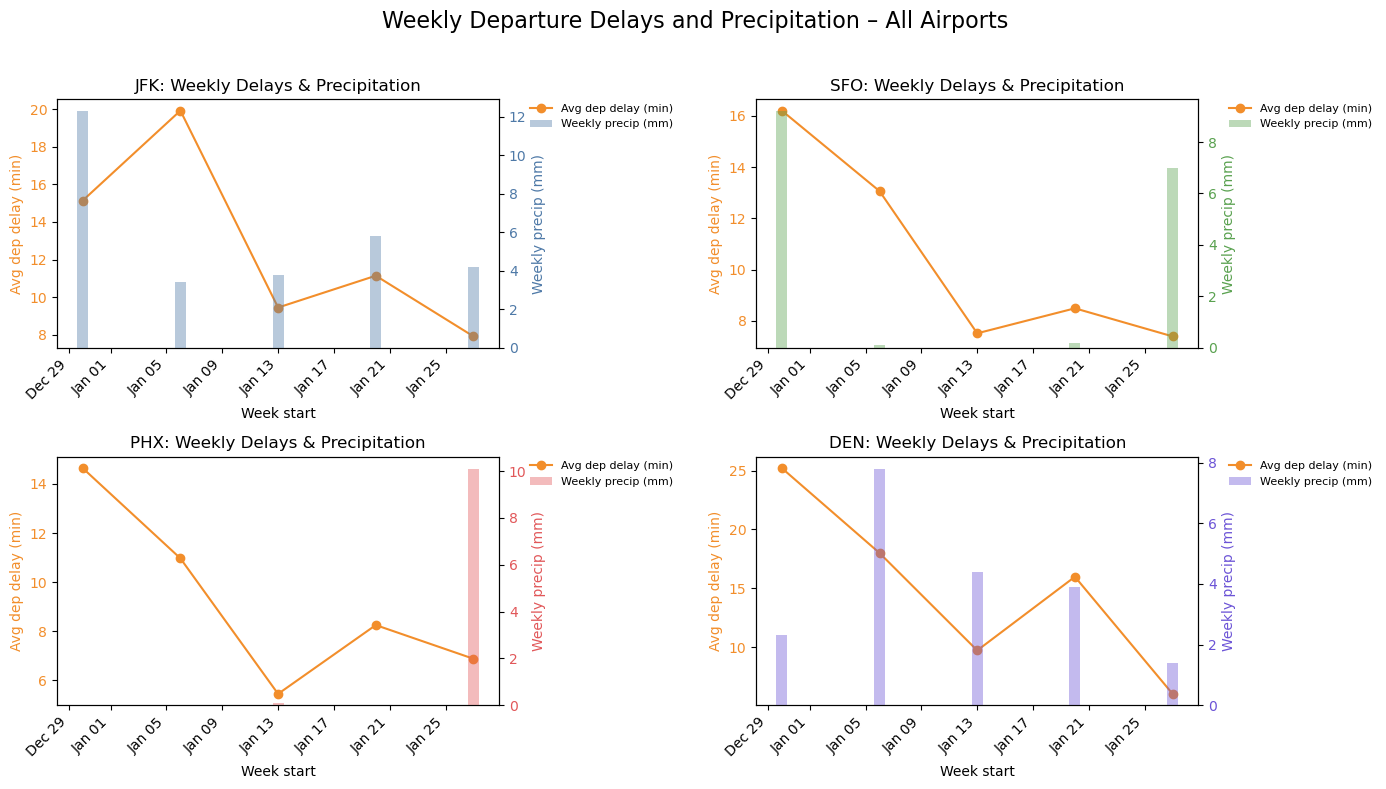

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# List of the 4 airports you care about (order = layout order)
airport_codes = ["JFK", "SFO", "PHX", "DEN"]

# Map IATA → airport_id
airport_map = dict(zip(airports["iata_code"], airports["airport_id"]))

# Bar colors for each airport subplot
bar_colors = {
    "JFK": "#4E79A7",   # blue
    "SFO": "#59A14F",   # green
    "PHX": "#E15759",   # red
    "DEN": "#6B53D6",   # orange-ish
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for ax, code in zip(axes, airport_codes):
    airport_id = airport_map[code]
    df_air = weekly[weekly["airport_id"] == airport_id].sort_values("week_start")

    # Line plot
    ax.plot(
        df_air["week_start"],
        df_air["avg_dep_delay_minutes"],
        color="#F28E2B",
        marker="o",
        label="Avg dep delay (min)"
    )
    ax.set_xlabel("Week start")
    ax.set_ylabel("Avg dep delay (min)", color="#F28E2B")
    ax.tick_params(axis="y", labelcolor="#F28E2B")

    # Bar plot
    ax2 = ax.twinx()
    ax2.bar(
        df_air["week_start"],
        df_air["weekly_precip_mm"],
        color=bar_colors[code],
        alpha=0.4,
        label="Weekly precip (mm)"
    )
    ax2.set_ylabel("Weekly precip (mm)", color=bar_colors[code])
    ax2.tick_params(axis="y", labelcolor=bar_colors[code])

    # Dates
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_title(f"{code}: Weekly Delays & Precipitation")

    # Combined legend OUTSIDE the subplot
    line_handles, line_labels = ax.get_legend_handles_labels()
    bar_handles, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        line_handles + bar_handles,
        line_labels + bar_labels,
        loc="upper left",
        bbox_to_anchor=(1.06, 1.0),
        borderaxespad=0,
        fontsize=8,
        frameon=False
    )



fig.suptitle("Weekly Departure Delays and Precipitation – All Airports", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle
plt.show()


JFK starts the month with the longest delays, which line up with the rain in the first week. Once the weather clears, average delay drops fast and stays lower for the rest of the month. The final week has almost no precipitation and delays settle around their lowest point.

SFO begins with both rain and higher delays, but the drop in precipitation after the first week matches a steady decline in delays. The last week brings another bump in rain, but delays don’t jump much, suggesting that late-month operations handled the weather better or that the storms were less disruptive.

Phoenix is mostly dry all month, and its delays fall in a smooth downward trend. The single wet week at the end doesn’t seem to push delays up, which fits with PHX generally being less sensitive to weather and more influenced by operational or demand factors.

Denver shows the strongest weather-delay link. The first two weeks have noticeable precipitation and also the highest delays. When the weather eases mid-month, delays drop sharply. The last week has very light precipitation and delays settle at their lowest point of January.

### 9.2 Plot 2 – Wind Speed vs departure delay (all airports)

This scatter plot combines all airports and weeks, with:

- x-axis: weekly wind speed (m/s)
- y-axis: average departure delay (minutes)

It helps visualize whether windier weeks tend to have higher delays overall.


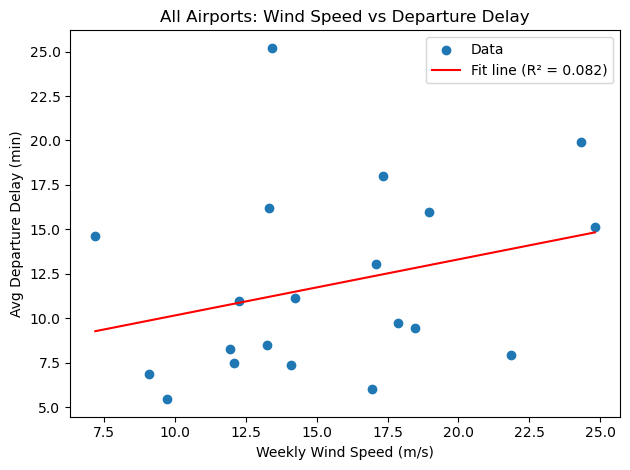

In [39]:
# Extract x and y
x = weekly["weekly_wind_speed_ms"]
y = weekly["avg_dep_delay_minutes"]

# Fit linear regression
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# Compute R²
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

# Plot
fig, ax = plt.subplots()
ax.scatter(x, y, label="Data")

# Sort values so the line draws cleanly
order = np.argsort(x)
ax.plot(x.iloc[order], y_pred[order], color="red", label=f"Fit line (R² = {r2:.3f})")

ax.set_xlabel("Weekly Wind Speed (m/s)")
ax.set_ylabel("Avg Departure Delay (min)")
ax.set_title("All Airports: Wind Speed vs Departure Delay")
ax.legend()

plt.tight_layout()
plt.show()


### Wind speed and departure delays: what the scatter shows

The points are widely scattered, and the trend line tilts upward only slightly. That small slope and the low R² tell you that higher weekly wind speeds don’t strongly predict higher delays across these airports. There’s a hint of a relationship, but it’s weak and inconsistent. Some of the longest delays happen during moderate wind weeks, and several low-delay weeks occur even when winds are fairly high. Overall, wind speed isn’t a major driver of departure delays in this dataset.

## 9.3 Plot 3 – Weekly departure delays by airport with temperature

This plot shows, for each week:

- Horizontal lollipops: weekly departure delay for each airport  
- Color shading: the average temperature during that week  
- Faceted layout: allows week-to-week comparisons while keeping each airport’s pattern easy to see  

I use this chart to compare how delays vary across airports within the same
week and to observe whether temperature differences might help explain shifts
in delay levels.


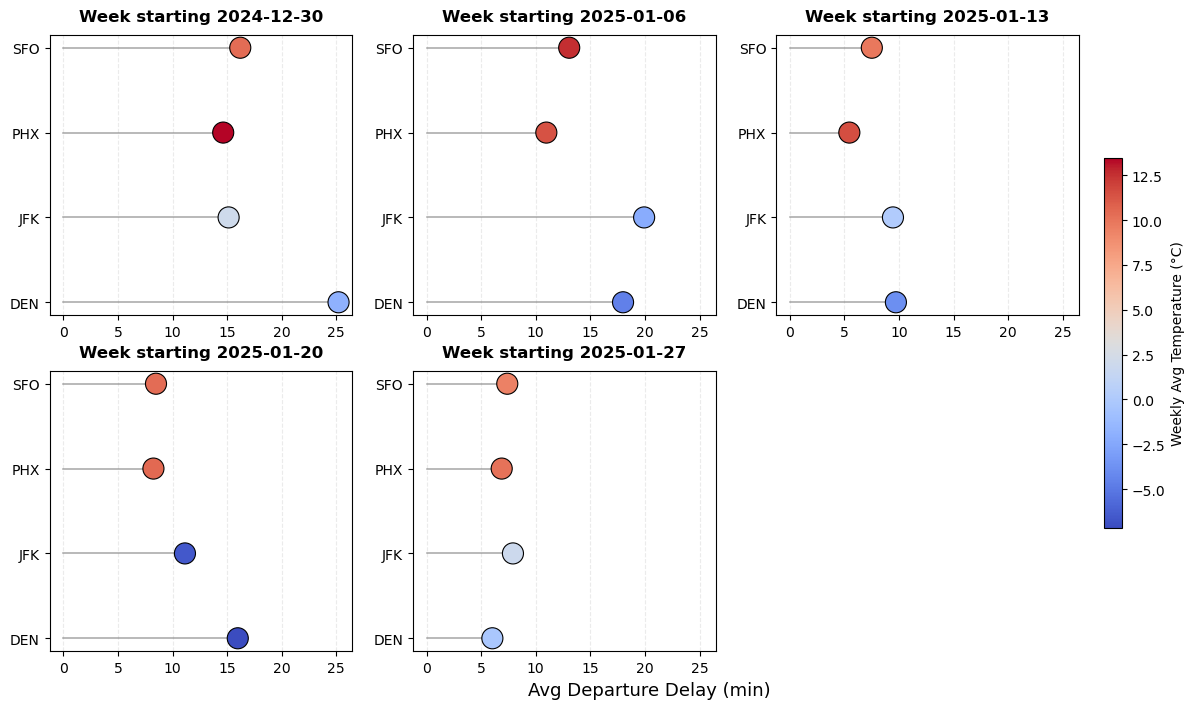

In [40]:
import matplotlib as mpl

df = weekly.copy()

# Map airport_id → IATA
airport_map = dict(zip(airports["airport_id"], airports["iata_code"]))
df["airport"] = df["airport_id"].map(airport_map)

weeks = sorted(df["week_start"].unique())
airports_list = sorted(df["airport"].unique())

# Temperature range
tmin = df["weekly_temp_avg_c"].min()
tmax = df["weekly_temp_avg_c"].max()

# 2 rows × 3 columns
n_weeks = len(weeks)
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 4 * n_rows),
    sharex=True
)

axes = np.array(axes).reshape(-1)

# Hide extra empty panel(s)
for ax in axes[n_weeks:]:
    ax.set_visible(False)

for ax, week in zip(axes, weeks):
    sub = df[df["week_start"] == week]

    y = np.arange(len(airports_list))
    delays = []
    temps = []

    for a in airports_list:
        row = sub[sub["airport"] == a]
        delays.append(row["avg_dep_delay_minutes"].iloc[0] if len(row) else np.nan)
        temps.append(row["weekly_temp_avg_c"].iloc[0] if len(row) else np.nan)

    delays = np.array(delays)
    temps = np.array(temps)

    # Normalize colors
    norm = (temps - tmin) / (tmax - tmin)
    colors = plt.cm.coolwarm(norm)

    # Light vertical grid
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    # Stems
    for yi, xi in zip(y, delays):
        ax.plot([0, xi], [yi, yi], color="gray", linewidth=1.1, alpha=0.7)

    # Dots (clip_off so edges never get cut)
    ax.scatter(
        delays, y,
        s=230,
        c=colors,
        edgecolors="black",
        linewidth=0.8,
        clip_on=False,
        zorder=3
    )

    # y-axis labels
    ax.set_yticks(y)
    ax.set_yticklabels(airports_list)

    # Week label on top
    week_label = f"Week starting {pd.to_datetime(week).date()}"
    ax.set_title(week_label, fontsize=12, weight="bold", pad=10)

    # Ensure x-axis ticks show on all subplots
    ax.tick_params(axis="x", labelbottom=True)

# Shared x-axis label
fig.supxlabel("Avg Departure Delay (min)", fontsize=13, y=0.05)

# Colorbar
sm = mpl.cm.ScalarMappable(
    cmap="coolwarm",
    norm=mpl.colors.Normalize(vmin=tmin, vmax=tmax)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes.tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Weekly Avg Temperature (°C)")

plt.show()

### Weekly temperature and departure delays: what the bubbles show:

Across the five weeks, a few patterns stand out:

Cooler airports tend to start the month with higher delays.
Denver is the clearest example. It’s the coldest location each week and also shows the highest delays in the first half of the month. As temperatures rise, its delays fall noticeably.

Warmer airports stay more stable.
Phoenix and San Francisco sit on the warm end of the scale, and their delays don’t swing as much. Phoenix shows a smooth decline in delays as the month goes on, even though its temperature barely changes. SFO stays relatively steady, with modest shifts in both temperature and delay.

JFK sits in the middle.
JFK begins with moderate delays during a cooler start and then settles down as temperatures rise a bit. It doesn't swing as sharply as Denver, but you still see a drop that lines up with mild warming.

Overall pattern.
There’s a loose link between temperature and delays, but it’s not tight. Cold weeks at cold airports tend to bring more delays, while warm airports stay fairly steady. The temperature gradient helps highlight this, but it’s clear that temperature alone doesn’t explain the full delay story.

## 10. Streamlit Dashboard Preparation

The final product of this project is an interactive Streamlit dashboard
that allows a user to:

- Choose an airport (JFK, SFO, PHX, DEN)
- View weekly delay metrics over time
- Compare delays with weekly precipitation
- See a scatter plot of precipitation vs delay

For simplicity, I export the final `weekly` DataFrame and the `airports`
dimension to CSV and then read those into a separate `app.py` Streamlit script.


In [41]:
# Export weekly metrics and airports to CSV for the Streamlit app
weekly.to_csv("weekly_flight_weather_metrics.csv", index=False)
airports.to_csv("airports.csv", index=False)
flights.to_csv("flights.csv", index=False)
daily_weather.to_csv("daily_weather.csv", index=False)

In [42]:
!pip install streamlit pyngrok

In [43]:
NGROK_AUTH_TOKEN = "36VGxvxAYgeBcNRKZ5kgBgLiq7L_47HB3et6xkXf54sVDkg7B"
from pyngrok import ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

In [44]:
import subprocess
import time
from pyngrok import ngrok

def start_streamlit():
    # Start Streamlit in the background

  # Kill previous tunnels if any
  ngrok.kill()

  # Start Streamlit in the background
  process = subprocess.Popen(
      ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
  )

  # Wait a bit for Streamlit to start
  time.sleep(5)

  # Create a public URL
  public_url = ngrok.connect(8501, "http")
  print("Public URL:", public_url)

start_streamlit()

Public URL: NgrokTunnel: "https://unpersonifying-jacinta-preanaphoral.ngrok-free.dev" -> "http://localhost:8501"


In [45]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
from datetime import datetime, date
import requests

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------------------------------------
# App title
# -------------------------------------------------------

st.set_page_config(page_title="Flight Delays & Weather – Jan 2025", layout="wide")
st.title("Flight Delays and Weather – January 2025 🌦️✈️")

# -------------------------------------------------------
# Load data
# -------------------------------------------------------

airports = pd.read_csv("airports.csv")
flights = pd.read_csv("flights.csv")
weekly = pd.read_csv("weekly_flight_weather_metrics.csv")
daily_weather = pd.read_csv("daily_weather.csv")

# Parse dates
if "FL_DATE" in flights.columns:
    flights["FL_DATE"] = pd.to_datetime(flights["FL_DATE"])

if "week_start" in weekly.columns:
    weekly["week_start"] = pd.to_datetime(weekly["week_start"])

if "date" in daily_weather.columns:
    daily_weather["date"] = pd.to_datetime(daily_weather["date"])

# Focus on the four airports
target_airports = ["JFK", "SFO", "PHX", "DEN"]
airports = airports[airports["iata_code"].isin(target_airports)].copy()
daily_weather = daily_weather[daily_weather["iata_code"].isin(target_airports)].copy()
flights = flights[flights["ORIGIN"].isin(target_airports)].copy()

# Attach iata_code to weekly if needed, then filter
if "iata_code" not in weekly.columns and "airport_id" in weekly.columns:
    weekly = weekly.merge(
        airports[["airport_id", "iata_code"]],
        on="airport_id",
        how="left"
    )
weekly = weekly[weekly["iata_code"].isin(target_airports)].copy()

# Make sure delay columns exist in flights
if "dep_delay_minutes" not in flights.columns and "DEP_DELAY" in flights.columns:
    flights["dep_delay_minutes"] = flights["DEP_DELAY"]

if "arr_delay_minutes" not in flights.columns and "ARR_DELAY" in flights.columns:
    flights["arr_delay_minutes"] = flights["ARR_DELAY"]

if "is_delayed_15" not in flights.columns:
    if "ARR_DEL15" in flights.columns:  # 0/1 flag in BTS data
        flights["is_delayed_15"] = flights["ARR_DEL15"]
    else:
        flights["is_delayed_15"] = (flights["arr_delay_minutes"] > 15).astype(int)

# -------------------------------------------------------
# Build DAILY joined dataset: delays + weather
# -------------------------------------------------------

daily_delays = (
    flights
    .groupby(["ORIGIN", "FL_DATE"], as_index=False)
    .agg(
        avg_dep_delay_minutes=("dep_delay_minutes", "mean"),
        avg_arr_delay_minutes=("arr_delay_minutes", "mean"),
        percent_delayed_15=("is_delayed_15", "mean"),
        num_flights=("FL_DATE", "count")
    )
)

daily_delays = daily_delays.merge(
    airports[["airport_id", "iata_code"]],
    left_on="ORIGIN",
    right_on="iata_code",
    how="left"
)

daily_delays = daily_delays.rename(columns={"FL_DATE": "date"})

daily_joined = daily_delays.merge(
    daily_weather[["airport_id", "date", "temp_avg_c", "precip_mm", "wind_speed_ms"]],
    on=["airport_id", "date"],
    how="left"
)

daily_joined = daily_joined.dropna(subset=["temp_avg_c", "precip_mm", "wind_speed_ms"])

# -------------------------------------------------------
# Open-Meteo helper (for live Jan 2025 weather plot)
# -------------------------------------------------------

def fetch_weather(lat, lon, start_date_str, end_date_str):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date_str,
        "end_date": end_date_str,
        "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
        "timezone": "UTC"
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data = resp.json()

    daily = data["daily"]
    df = pd.DataFrame({
        "date": pd.to_datetime(daily["time"]),
        "temp_avg_c": daily["temperature_2m_mean"],
        "precip_mm": daily["precipitation_sum"],
        "wind_speed_ms": daily["windspeed_10m_max"],
    })
    return df

# -------------------------------------------------------
# Page 1 – Welcome
# -------------------------------------------------------

def welcome_page():
    st.header("Welcome 🎓")

    left, right = st.columns([2, 1])
    with left:
        st.markdown(
            """
            This app is my **Data Engineering final project**.

            It explores how **daily weather** relates to **flight delays** for four airports
            during **January 2025**:

            - JFK – New York, NY  
            - SFO – San Francisco, CA  
            - PHX – Phoenix, AZ  
            - DEN – Denver, CO  

            **Pipeline summary:**

            1. Ingested January 2025 flight data (BTS On-Time Performance).
            2. Pulled daily historical weather from the Open-Meteo API.
            3. Cleaned and joined the data into a relational model.
            4. Aggregated to daily metrics combining delays and weather.
            5. Built this Streamlit dashboard as the final interface.
            """
        )
    with right:
        st.subheader("Quick stats")
        st.metric("Airports", len(target_airports))
        st.metric("Flights in dataset", len(flights))
        st.metric("Days with data", daily_joined["date"].nunique())

    st.info(
        "Use the sidebar to switch between: January weather, "
        "a flight report, and daily weather vs delay visualizations."
    )

# -------------------------------------------------------
# Page 2 – January 2025 Weather (Open-Meteo, Plotly)
# -------------------------------------------------------

def january_forecast_page():
    st.header("January 2025 Daily Weather (Open-Meteo)")

    airport_options = airports["iata_code"].tolist()
    selected_airport = st.selectbox("Select airport", airport_options)

    airport_row = airports[airports["iata_code"] == selected_airport].iloc[0]
    lat = airport_row["latitude"]
    lon = airport_row["longitude"]

    st.write("Select a date range in **January 2025** to see daily weather.")

    col1, col2 = st.columns(2)
    with col1:
        start_date = st.date_input("Start date", value=date(2025, 1, 1))
    with col2:
        end_date = st.date_input("End date", value=date(2025, 1, 31))

    jan_start = date(2025, 1, 1)
    jan_end = date(2025, 1, 31)
    if start_date < jan_start:
        start_date = jan_start
    if end_date > jan_end:
        end_date = jan_end

    if start_date > end_date:
        st.error("Start date must be on or before end date.")
        return

    if st.button("Get weather"):
        try:
            df_weather = fetch_weather(
                lat,
                lon,
                start_date.strftime("%Y-%m-%d"),
                end_date.strftime("%Y-%m-%d")
            )
        except Exception as e:
            st.error(f"Error fetching weather: {e}")
            return

        st.subheader(f"Daily weather for {selected_airport}")
        st.dataframe(df_weather)

        # combined bar (precip) + line (temp) with Plotly
        fig = make_subplots(
            specs=[[{"secondary_y": True}]],
        )

        fig.add_trace(
            go.Bar(
                x=df_weather["date"],
                y=df_weather["precip_mm"],
                name="Daily precipitation (mm)",
                marker_color="#4A90E2",
                opacity=0.7,
            ),
            secondary_y=False,
        )

        fig.add_trace(
            go.Scatter(
                x=df_weather["date"],
                y=df_weather["temp_avg_c"],
                name="Avg temperature (°C)",
                mode="lines+markers",
                line=dict(color="#F5A623", width=2),
                marker=dict(size=6),
            ),
            secondary_y=True,
        )

        fig.update_layout(
            template="plotly_white",
            title=f"{selected_airport}: Daily Precipitation and Temperature",
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=-0.25,
                xanchor="center",
                x=0.5
            ),
            margin=dict(l=40, r=40, t=60, b=80),
            height=500,
        )

        fig.update_xaxes(
            title_text="Date",
            tickformat="%b %d",
            tickangle=-45
        )
        fig.update_yaxes(title_text="Daily precipitation (mm)", secondary_y=False)
        fig.update_yaxes(title_text="Average daily temperature (°C)", secondary_y=True)

        st.plotly_chart(fig, use_container_width=True)

# -------------------------------------------------------
# Page 3 – January 2025 Flight Report (table + simple chart)
# -------------------------------------------------------

def _format_hhmm(x):
    """Convert 802 -> '08:02', handle NaN / blanks safely."""
    if pd.isna(x):
        return None
    try:
        x = int(x)
        hh = x // 100
        mm = x % 100
        return f"{hh:02d}:{mm:02d}"
    except Exception:
        return None

def january_flight_report_page():
    st.header("January 2025 Flight Report")

    st.write(
        """
        This page summarizes **January 2025 flights** whose origin is one of
        JFK, SFO, PHX, or DEN.

        Use the origin selector to see how often flights from each airport are
        delayed and how delay rates change across days in January 2025.
        """
    )

    # -------------------------
    # Filter widgets
    # -------------------------
    origin_options = sorted(flights["ORIGIN"].unique().tolist())

    selected_origins = st.multiselect(
        "Origin airport(s)",
        options=origin_options,
        default=origin_options,
    )

    # -------------------------
    # Apply filters (full month, no date widgets)
    # -------------------------
    mask = flights["ORIGIN"].isin(selected_origins)
    filtered = flights.loc[mask].copy()

    if filtered.empty:
        st.info("No flights match the selected filters.")
        return

    # Ensure is_delayed_15 exists
    if "is_delayed_15" not in filtered.columns:
        if "ARR_DEL15" in filtered.columns:
            filtered["is_delayed_15"] = filtered["ARR_DEL15"]
        else:
            filtered["is_delayed_15"] = (
                filtered.get("arr_delay_minutes", 0) > 15
            ).astype(int)

    # -------------------------
    # Fix time formatting for display
    # -------------------------
    if "DEP_TIME" in filtered.columns:
        filtered["DEP_TIME_LOCAL"] = filtered["DEP_TIME"].apply(_format_hhmm)
    if "ARR_TIME" in filtered.columns:
        filtered["ARR_TIME_LOCAL"] = filtered["ARR_TIME"].apply(_format_hhmm)

    # -------------------------
    # KPI cards
    # -------------------------
    total_flights = len(filtered)
    avg_dep_delay = filtered.get("dep_delay_minutes", pd.Series(dtype=float)).mean()
    pct_delayed = filtered["is_delayed_15"].mean() * 100

    m1, m2, m3 = st.columns(3)
    m1.metric("Flights in view", f"{total_flights:,}")
    if not np.isnan(avg_dep_delay):
        m2.metric("Avg departure delay (min)", f"{avg_dep_delay:,.1f}")
    else:
        m2.metric("Avg departure delay (min)", "N/A")
    m3.metric("% of flights delayed ≥ 15 min", f"{pct_delayed:,.1f}%")

    # -------------------------
    # Donut charts by origin & delay status
    # -------------------------
    st.subheader("Delay breakdown by origin")

    filtered["delay_label"] = np.where(
        filtered["is_delayed_15"] == 1,
        "Delayed (≥ 15 min)",
        "Not delayed (< 15 min)",
    )

    fig_pie = px.pie(
        filtered,
        names="delay_label",
        facet_col="ORIGIN",
        facet_col_wrap=2,  # 2x2 layout for 4 airports
        hole=0.5,          # donut
        category_orders={
            "delay_label": ["Not delayed (< 15 min)", "Delayed (≥ 15 min)"],
            "ORIGIN": sorted(filtered["ORIGIN"].unique()),
        },
        labels={
            "delay_label": "Delay status",
            "ORIGIN": "Origin airport",
        },
        template="plotly_white",
        color="delay_label",
        color_discrete_map={
            "Not delayed (< 15 min)": "#d3d3d3",
            "Delayed (≥ 15 min)": "#d62728",
        },
    )

    fig_pie.update_traces(textposition="inside", textinfo="percent+label")
    fig_pie.update_layout(
        height=600,
        margin=dict(l=40, r=40, t=80, b=40),
        legend_title="Delay status",
    )

    st.plotly_chart(fig_pie, use_container_width=True)

    # -------------------------
    # NEW: % delayed by day-of-month, faceted by origin
    # -------------------------
    if "FL_DATE" in filtered.columns:
        st.subheader("Percent of flights delayed by day of month")

        # Day of month (1–31)
        filtered["day_of_month"] = filtered["FL_DATE"].dt.day

        day_df = (
            filtered.groupby(["ORIGIN", "day_of_month"], as_index=False)
            .agg(
                pct_delayed=("is_delayed_15", "mean"),
                num_flights=("is_delayed_15", "size"),
            )
        )
        if day_df.empty:
            st.info("No data to show by day of month.")
        else:
            day_df["pct_delayed"] = day_df["pct_delayed"] * 100.0

            # Consistent color per airport
            airport_colors = {
                "JFK": "#1f77b4",  # blue
                "SFO": "#2ca02c",  # green
                "PHX": "#ff7f0e",  # orange
                "DEN": "#9467bd",  # purple
            }

            fig_day = px.bar(
                day_df,
                x="day_of_month",
                y="pct_delayed",
                facet_col="ORIGIN",
                facet_col_wrap=2,
                color="ORIGIN",
                color_discrete_map=airport_colors,
                category_orders={
                    "ORIGIN": sorted(day_df["ORIGIN"].unique()),
                },
                labels={
                    "day_of_month": "Day of month (Jan 2025)",
                    "pct_delayed": "Flights delayed ≥ 15 min (%)",
                    "ORIGIN": "Origin airport",
                },
                template="plotly_white",
            )

            fig_day.update_yaxes(range=[0, 100])
            fig_day.update_layout(
                height=650,
                margin=dict(l=40, r=40, t=60, b=60),
                showlegend=False,
            )

            st.plotly_chart(fig_day, use_container_width=True)

            st.caption(
                "Each panel shows the percent of flights that were delayed at least "
                "15 minutes on each day of January 2025, for that origin airport."
            )

    # -------------------------
    # Detailed table in an expander
    # -------------------------
    with st.expander("Show detailed flight table"):
        cols_to_show = [
            c
            for c in [
                "FL_DATE",
                "ORIGIN",
                "DEST",
                "DEP_TIME_LOCAL",
                "ARR_TIME_LOCAL",
                "dep_delay_minutes",
                "arr_delay_minutes",
                "is_delayed_15",
            ]
            if c in filtered.columns
        ]

        st.dataframe(
            filtered[cols_to_show].sort_values(["FL_DATE", "ORIGIN", "DEST"])
        )

# ------------------------------------------------------- 
# Page 4 – Daily Weather vs Daily Flight Delays (Plotly) 
# -------------------------------------------------------
def weather_vs_delays_page():
    st.header("Daily Weather vs Daily Flight Delays")

    st.write(
        """
        This page uses a **daily** dataset that joins:

        - average departure and arrival delay per day per airport  
        - daily weather (temperature, precipitation, wind speed)

        Each mark in the chart is **one airport on one day**.
        """
    )

    airport_codes = sorted(daily_joined["iata_code"].dropna().unique().tolist())
    selected_airports = st.multiselect(
        "Airport(s)",
        options=airport_codes,
        default=airport_codes
    )

    min_date = daily_joined["date"].min().date()
    max_date = daily_joined["date"].max().date()
    date_range = st.date_input(
        "Date range",
        value=(min_date, max_date),
        min_value=min_date,
        max_value=max_date
    )

    if isinstance(date_range, tuple):
        start_date, end_date = date_range
    else:
        start_date = end_date = date_range

    weather_var_options = {
        "Daily average temperature (°C)": "temp_avg_c",
        "Daily precipitation (mm)": "precip_mm",
        "Daily max wind speed (m/s)": "wind_speed_ms"
    }
    weather_label = st.selectbox(
        "Weather variable",
        list(weather_var_options.keys())
    )
    weather_col = weather_var_options[weather_label]

    df = daily_joined[
        (daily_joined["iata_code"].isin(selected_airports)) &
        (daily_joined["date"].dt.date >= start_date) &
        (daily_joined["date"].dt.date <= end_date)
    ].copy()

    if df.empty:
        st.warning("No data for the selected filters.")
        return

    # --------------------------------------------------
    # Main visualization: conditional on weather variable
    # --------------------------------------------------
    if weather_col == "precip_mm":
        st.subheader("Daily precipitation by airport")

        fig_main = px.bar(
            df.sort_values("date"),
            x="date",
            y="precip_mm",
            facet_col="iata_code",
            facet_col_wrap=2,  # 2x2 layout for 4 airports
            color="iata_code",
            labels={
                "date": "Date",
                "precip_mm": "Daily precipitation (mm)",
                "iata_code": "Airport",
            },
            template="plotly_white",
        )
        fig_main.update_layout(
            height=500,
            margin=dict(l=40, r=40, t=60, b=60),
            showlegend=False,
        )
        fig_main.update_xaxes(tickformat="%b %d", tickangle=-45)
    else:
        st.subheader("Scatter: weather vs average departure delay (daily)")

        fig_main = px.scatter(
            df,
            x=weather_col,
            y="avg_dep_delay_minutes",
            color="iata_code",
            hover_data=["date", "num_flights"],
            labels={
                weather_col: weather_label,
                "avg_dep_delay_minutes": "Avg departure delay (min)",
                "iata_code": "Airport"
            },
            template="plotly_white",
            trendline="ols"
        )
        fig_main.update_layout(
            height=500,
            legend_title="Airport",
            margin=dict(l=40, r=40, t=40, b=40)
        )

    st.plotly_chart(fig_main, use_container_width=True)

    # --------------------------------------------------
    # Line chart of delay over time (unchanged)
    # --------------------------------------------------
    st.subheader("Daily average departure delay over time")

    fig_line = px.line(
        df.sort_values("date"),
        x="date",
        y="avg_dep_delay_minutes",
        color="iata_code",
        labels={
            "date": "Date",
            "avg_dep_delay_minutes": "Avg departure delay (min)",
            "iata_code": "Airport"
        },
        template="plotly_white",
    )
    fig_line.update_layout(
        height=450,
        legend_title="Airport",
        margin=dict(l=40, r=40, t=40, b=40),
        xaxis=dict(tickformat="%b %d", tickangle=-45)
    )
    st.plotly_chart(fig_line, use_container_width=True)

    with st.expander("Show daily joined data"):
        st.dataframe(
            df[
                [
                    "date",
                    "iata_code",
                    "avg_dep_delay_minutes",
                    "avg_arr_delay_minutes",
                    "percent_delayed_15",
                    "temp_avg_c",
                    "precip_mm",
                    "wind_speed_ms",
                    "num_flights"
                ]
            ].sort_values(["iata_code", "date"])
        )


# -------------------------------------------------------
# Sidebar navigation
# -------------------------------------------------------

pages = {
    "Welcome": welcome_page,
    "January 2025 Weather": january_forecast_page,
    "January 2025 Flight Report": january_flight_report_page,
    "Daily Weather vs Delays": weather_vs_delays_page
}


if "current_page" not in st.session_state:
    st.session_state.current_page = "Welcome"

def sidebar_navigation():
    with st.sidebar:
        st.markdown("### Menu")

        for page_name in pages.keys():
            if st.button(page_name):
                st.session_state.current_page = page_name
                st.rerun()


sidebar_navigation()
pages[st.session_state.current_page]()


Writing app.py


In [46]:
start_streamlit()

Public URL: NgrokTunnel: "https://unpersonifying-jacinta-preanaphoral.ngrok-free.dev" -> "http://localhost:8501"
